# Logistic Regression Baseline

## Imports

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## Load Dataset

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
image_dir = "../data/raw/train_images/"

train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


## Feature Extraction Functions

### Brightness

In [4]:
def calc_brightness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return gray.mean()

### Blurriness (Laplacian Variance)

In [5]:
def calc_blurriness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

### Color Stats (Mean + Std for R,G,B)

In [6]:
def color_stats(img):
    means = img.mean(axis=(0,1))          # R,G,B mean
    stds  = img.std(axis=(0,1))           # R,G,B std dev
    return np.concatenate([means, stds])

### Entropy (Texture complexity)

In [7]:
def calc_entropy(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([gray],[0],None,[256],[0,256]).ravel()
    hist /= hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

## Extract Features for all Images

In [8]:
features = []
labels = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_id = row["id_code"]
    diagnosis = row["diagnosis"]
    
    path = os.path.join(image_dir, f"{img_id}.png")
    img = np.array(Image.open(path).convert("RGB"))
    
    # Feature extraction
    brightness = calc_brightness(img)
    blurriness = calc_blurriness(img)
    entropy = calc_entropy(img)
    color = color_stats(img)
    height, width, _ = img.shape
    
    feat_vec = [brightness, blurriness, entropy, width, height] + list(color)
    
    features.append(feat_vec)
    labels.append(diagnosis)

features = np.array(features)
labels = np.array(labels)

print("Feature matrix shape:", features.shape)

100%|██████████| 3662/3662 [18:59<00:00,  3.21it/s] 

Feature matrix shape: (3662, 11)


## Train–Validation Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    features, labels, test_size=0.20, random_state=42, stratify=labels
)

X_train.shape, X_val.shape

((2929, 11), (733, 11))

## Scale Features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

## Train Logistic Regression Model

In [14]:
model = LogisticRegression(
    max_iter=5000,           
    solver='lbfgs',
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_val_scaled)

## Evaluation

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

# ------------------------------------
# Compute Metrics
# ------------------------------------
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="macro", zero_division=0)
rec = recall_score(y_val, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_val, y_pred)

# ------------------------------------
# Print Metrics
# ------------------------------------
print("===== Logistic Regression Metrics =====")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec:.4f}")
print(f"Recall (macro):      {rec:.4f}")
print(f"F1-score (macro):    {f1:.4f}")
print(f"Balanced Accuracy:   {bal_acc:.4f}")
print("=======================================")

===== Logistic Regression Metrics =====
Accuracy:            0.6317
Precision (macro):   0.4328
Recall (macro):      0.4405
F1-score (macro):    0.4234
Balanced Accuracy:   0.4405


In [ ]:


print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, digits=4))

Accuracy: 0.6316507503410641
              precision    recall  f1-score   support

           0     0.9053    0.9003    0.9028       361
           1     0.3208    0.4595    0.3778        74
           2     0.6641    0.4250    0.5183       200
           3     0.1310    0.2821    0.1789        39
           4     0.1429    0.1356    0.1391        59

    accuracy                         0.6317       733
   macro avg     0.4328    0.4405    0.4234       733
weighted avg     0.6779    0.6317    0.6449       733



### Confusion Matrix

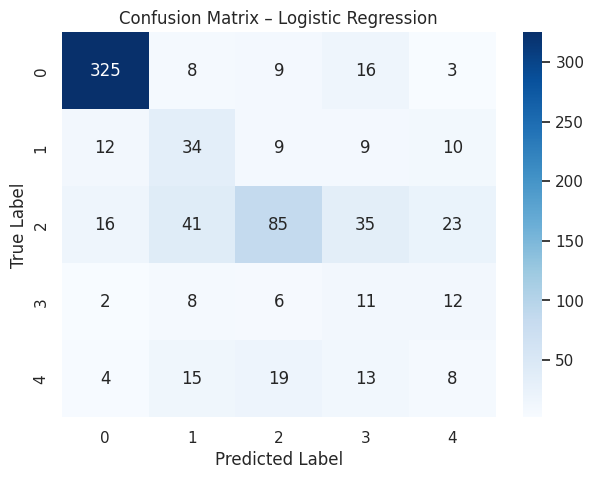

In [16]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

### Feature Importance Plot

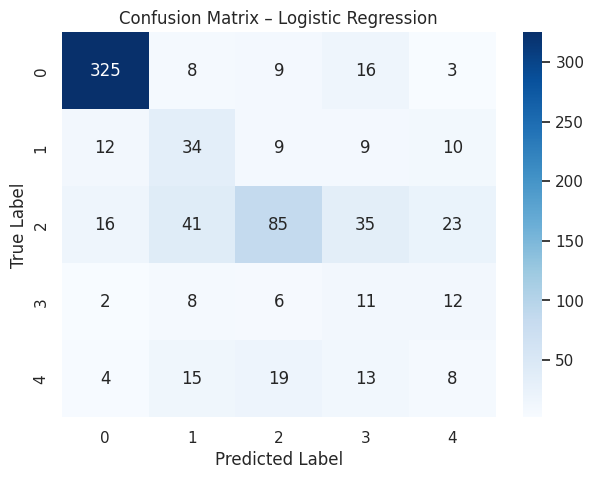

Diagonal sum: 463
Total: 733
Acc from CM: 0.6316507503410641


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

print("Diagonal sum:", np.trace(cm))
print("Total:", cm.sum())
print("Acc from CM:", np.trace(cm)/cm.sum())

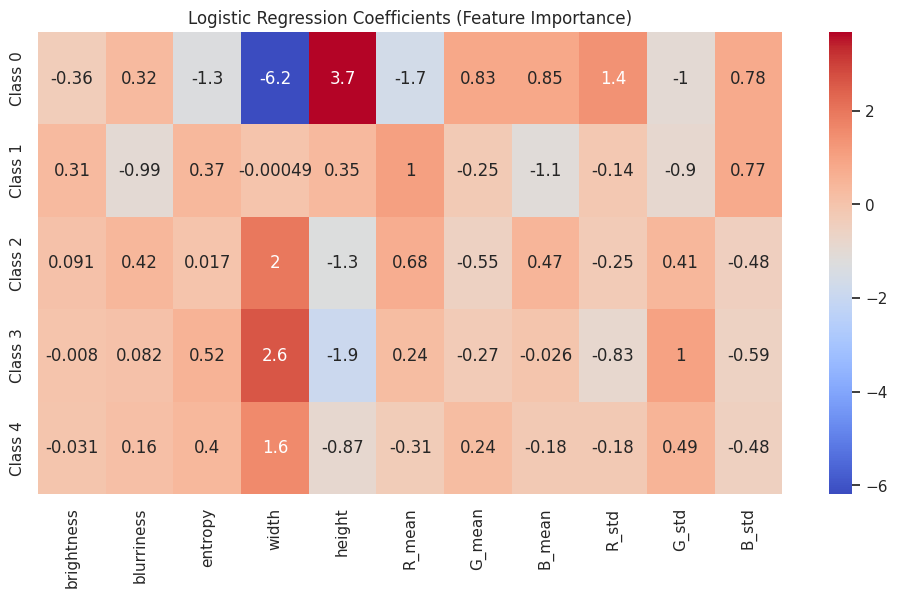

In [18]:
coef = model.coef_  # shape: (5 classes, n_features)

feature_names = [
    "brightness", "blurriness", "entropy",
    "width", "height",
    "R_mean", "G_mean", "B_mean",
    "R_std", "G_std", "B_std"
]

plt.figure(figsize=(12,6))
sns.heatmap(coef, annot=True, cmap="coolwarm",
            xticklabels=feature_names,
            yticklabels=[f"Class {i}" for i in range(5)])
plt.title("Logistic Regression Coefficients (Feature Importance)")
plt.show()